# DHBW Machine Learning: R2-D2

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor, plot_tree

## Buisiness & Data Understanding

### Überblick über den Datensatz




#### Problembeschreibung
In Bike-Sharing-Systemen besteht das zentrale Problem darin, die richtige Anzahl an Fahrrädern zur richtigen Zeit bereitzustellen. Wenn zu wenige Fahrräder zur Verfügung stehen, gibt es unzufriedene Kunden und verlorene Nachfrage, während das Problem bei zu vielen Fahrrädern eine ineffiziente Ressourcennutzung und höhere Kosten mit sich bringt. Das Ziel ist daher eine Vorhersage für die stündliche Nachfrage. 

#### Anwendungskontext
In vielen Großstädten weltweit wie z.B. in Seoul wurden Bike-Sharing-Systeme eingeführt, um den Verkehr zu entlasten, die nachhaltige Mobilität zu födern und bequemer zu machen und die letzte Strecke im öffentlichen Verkehr abzudecken. Das operative Problem ist die Frage, wie viele Fahrräder müssen zu einem bestimmten Zeitpunkt bereitstehen, um die Nachfrage zu bedienen. Denn die Nutzer erwarten sofortige Verfügbarkeit. Fehlende Fahrräder führen zur Frustation, mehr Wartezeit als geplant und die Abwanderung zu Alternativen. Gleichzeitig führen aber zu viele Fahrräder an einem Standort zur ineffizienten Nutzung. Die Nachfrage ist schwankend und wird beeinflusst durch die durch zeitliche Faktoren, Wetterbedingungen und saisonale Effekte. 
#### Zielsetzung
Ziel es deshalb, die Prognose der stündlich benötigten Fahrradanzahl, um eine zuverlässige und kontinuierliche Verfügbarkeit von Mietfahrrädern zu gewährleisten.
#### Erfolgskriterien
Business Kriterien: Reduktion von Leerständen und Engpässen, höhere Kundenzufriedenheit, effizientere Nutzung
Data Mining Kriterien: Geringer Prognosefehler

#### Überblick über den Datensatz und die Variablen

Der Datensatz besteht aus 8760 Beobachtungen(stündlich für ein Jahr) im Zeitraum von Dezember 2017 bis Dezember 2018. DIe Zielvariable ist der " Rented Bike Count " (Anzahl gemieteter Fahrräder pro Stunde). Der Datentyp ist multivariat. Es handelt sich um einen multivariaten Datensatz, der im Kontext eines Regressionsproblems analysiert wird.

##### Datentypen
Numerisch: Rented Bike Count (Zielvariable), Temperature, Humidity, Wind speed, Visibility, Dew point temperature, Solar radiation, Rainfall, Snowfall

Kategorisch: Seasons, Holiday, Functioning Day

Zyklisch: Date, Hour

#### Explorative Datenanalyse
Im Rahmen der explorativen Datenanalyse wurde der Datensatz untersucht, um zentrale Muster und Einflussfaktoren auf die Zielvariable „Rented Bike Count“ zu identifizieren. Dabei zeigt sich, dass die Nachfrage nach Mietfahrrädern stark variiert und typischerweise rechtsschief verteilt ist, mit wenigen hohen Spitzenwerten.
Ein wesentlicher Einflussfaktor ist die Zeit. Die Nachfrage weist klare tägliche Muster auf, mit Peaks in den Morgen- und Abendstunden (Pendlerverkehr) sowie niedriger Nutzung in der Nacht. Zudem unterscheiden sich Werktage und Wochenenden, wobei an Werktagen ausgeprägtere Nutzungsspitzen auftreten.
Auch Wetterbedingungen spielen eine zentrale Rolle. Die Temperatur korreliert positiv mit der Nachfrage, während Niederschlag und Schneefall diese deutlich reduzieren. Saisonale Effekte sind ebenfalls erkennbar, im Sommer ist die Nutzung höher als im Winter.

In [5]:
data = pd.read_csv("SeoulBikeData.csv")
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
data.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## Data Preparation

### Umgang mit fehlenden Werten

In diesem Datensatz sind keine fehlende Werte vorhanden.

In [7]:
data.isna().values.any()

np.False_

### Codierung von Variablen


#### Feature Selection

`Date` wird entfernt, da relevante Informationen durch `Temperatur`,`Season` und `Holiday` gegeben sind.

In [8]:
data = data.drop(columns="Date")

#### Qualitative Variablen

`Season`,`Holiday` und `Functioning Day` werden mit Dummy Variablen codiert.

In [9]:
# vier Jahreszeiten
data["Seasons"].unique()

<ArrowStringArray>
['Winter', 'Spring', 'Summer', 'Autumn']
Length: 4, dtype: str

In [10]:
# binäre Variable
data["Holiday"].unique()

<ArrowStringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str

In [11]:
# binäre Variable
data["Functioning Day"].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [12]:
# neue Spalten:
#   3 Spalten für Jahreszeiten
#   jeweils eine Spalte für binäre Variablen
data_encoded = pd.get_dummies(
    data=data, columns=["Seasons", "Holiday", "Functioning Day"], drop_first=True
)
data_encoded.select_dtypes(include=bool).head()

,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,False,False,True,True,True
1,False,False,True,True,True
2,False,False,True,True,True
3,False,False,True,True,True
4,False,False,True,True,True


#### Zyklische Variable

`Hour` stellt die Tageszeit als Stunde dar. Die Werte liegen zwischen 0 und 23.

Bei Modellen, die den Abstand von zwei Werten betrachten, wäre die Differenz von 0 und 23 sehr groß. Währendessen stellen diese Datenpunkte in der Realität nur eine Stunde Unterschied dar.

In [13]:
data["Hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

Wir codieren diese Variable mit zwei neuen Spalten, die geometrisch einen Kreis darstellen. Damit hätten die neuen Spalten für `Hour=0` und `Hour=23` sehr ähnliche Werte.

In [14]:
max_hour = 24

data_encoded["hour_sin"] = np.round(
    np.sin(2 * np.pi * data_encoded["Hour"] / max_hour), 4
)
data_encoded["hour_cos"] = np.round(
    np.cos(2 * np.pi * data_encoded["Hour"] / max_hour), 4
)

data_encoded[["hour_sin", "hour_cos", "Hour"]].head(24)

,hour_sin,hour_cos,Hour
0,0.0000,1.0000,0
1,0.2588,0.9659,1
2,0.5000,0.8660,2
3,0.7071,0.7071,3
4,0.8660,0.5000,4
5,0.9659,0.2588,5
6,1.0000,0.0000,6
7,0.9659,-0.2588,7
8,0.8660,-0.5000,8
9,0.7071,-0.7071,9


In [15]:
data_encoded = data_encoded.drop(columns="Hour")

### Skalierung

Bei Modellen, die mit Metriken arbeiten, wie z.B. der euklidischen Distanz, werden die Daten innerhalb einer Pipeline direkt vor dem eigentlichen Modell skaliert.

### Aufteilung der Daten

#### Zielvariable
Die Zielvariable soll die ausgeliehenen Fahrräder an einem gegeben Tag sein.

In [16]:
target = "Rented Bike Count"
X = data_encoded.drop(columns=[target])
y = data_encoded[target]

#### Aufteilung in Trainings- und Testdaten

Der Split wird in 80% Trainingsdaten und 20% Testdaten aufgeteilt. Die Testdaten werden vorerst nicht benutzt, um Modelle zu trainieren und zu evaluieren.

Erst nach dem iterativem Modeling werden die Testdaten eingesetzt, um das beste Modell schlussendlich zu bewerten.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17
)

## Modeling



Das beste Modell jedes Algorithmus' wird anhand des mittleren quadratischen Fehlers (`neg_mean_squared_error` für die cross validation) in einem 5-split K-Fold ermittelt.

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=17)

Wir speichern außerdem für jedes berechnete Modell den Trainingsfehler und den Testfehler in einem Dataframe, um am Ende noch einen Blick auf alles zu werfen.

In [19]:
best_models = pd.DataFrame(columns=["train_rmse", "test_rmse"])

In [20]:
def get_and_save_rmse(model_name: str, grid_search: GridSearchCV):
    best_index = grid_search.best_index_
    train_score = -grid_search.cv_results_['mean_train_score'][best_index]
    test_score = -grid_search.cv_results_['mean_test_score'][best_index]
    
    print(f"Train RMSE: {np.sqrt(train_score)}")
    print(f"Test RMSE: {np.sqrt(test_score)}")

    best_models.loc[model_name] = [np.sqrt(train_score), np.sqrt(test_score)]

### Ausschluss von unpassenden Modellen

Klassifikationsmodelle werden hier ausgeschlossen da es sich um ein Regressionsproblem handelt. Diese sind für Kategorien (z.B. Ja / Nein) gedacht. Wir wollen aber eine Menge an Fahrrädern vorhersagen, keine Klasse.

### Lineare Regression

In [21]:
lr_model = LinearRegression()
results = cross_validate(
    lr_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_squared_error",
    return_train_score=True,
)
test_error_mean = -results["test_score"].mean()
train_error_mean = -results["train_score"].mean()

print(f"Test RMSE: {np.sqrt(test_error_mean)}")
print(f"Train RMSE: {np.sqrt(train_error_mean)}")

Test RMSE: 434.82756072187465
Train RMSE: 433.46702035914234


Das Modell der linearen Regression hat eine sehr niedrige Varianz, was man an dem geringen Unterschied der Fehler sehen kann.

Man kann annehmen, dass das Modell einen hohen Bias hat, da der Fehler über 60% vom Durchschnitt von `Rented Bike Count` abweicht (704.6).

Wir nehmen an, dass die Lineare Regression die komplexen Daten nicht gut darstellen kann, da zum Beispiel Peaks zu Pendlerzeiten oder an Wochenden nicht getroffen werden können.

In [22]:
best_models.loc["Linear Regression"] = [np.sqrt(train_error_mean), np.sqrt(test_error_mean)]

### Regularisierung mit Lasso- und Ridge-Regression

Die lineare Regression hat eine sehr niedrige Varianz. Deshalb macht es wenig Sinn eine Regularisierung (eine Methode zur Reduktion der Varianz / Vermeidung von Overfitting) durchzuführen.

### Polynomiale Regression


Da wir vermuten, dass Variablen wie die Temperatur keinen rein linearen Effekt haben (zu kalt = wenig Räder, perfekt = viele Räder, zu heiß = wieder weniger), erweitern wir das Modell um polynomielle Features.

In [23]:
polypipe = Pipeline(
    [
        ("polynomial", PolynomialFeatures(include_bias=False)),
        ("linear_regression", LinearRegression()),
    ]
)

In [24]:
grid_search = GridSearchCV(
    estimator=polypipe,
    param_grid={
        "polynomial__degree": [2, 3],
    },
    cv=kfold,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [25]:
get_and_save_rmse("Polynomial Regression", grid_search)

Train RMSE: 297.2254078021151
Test RMSE: 311.42119195620364


Das Modell der polynomialen Regression mit Grad 2 hat schon eine etwas höhere Varianz wie die lineare Regression.

Der Fehler ist allerdings immernoch relativ hoch, was immernoch für einen hohen Bias spricht.

### Regression Tree with Cost Complexity Pruning

In [26]:
# Baum mit keiner maximalen Tiefe zur Berechnung von Cost complexity alphas
fulltree = DecisionTreeRegressor(random_state=17)
path = fulltree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[
    :-1:100
]  # Reduktion auf 1/100 der Werte aufgrund von Laufzeit und Ähnlichkeit der Werte (6100+ -> 61)
ccp_alphas.shape

(62,)

In [27]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=17),
    param_grid={"ccp_alpha": ccp_alphas, "max_depth": [3, 5, 10, 20]},
    cv=kfold,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': array([0.0000...93552426e+02]), 'max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [28]:
get_and_save_rmse("Decision Tree with Pruning", grid_search)

Train RMSE: 194.68027856998498
Test RMSE: 291.12173974942624


Hier fällt auf, dass die Differenz des Trainings- und Testfehlers wesentlich höher ist, als bei den Modellen zuvor. Das spricht für eine höhere Varianz, was zu Overfitting führt.

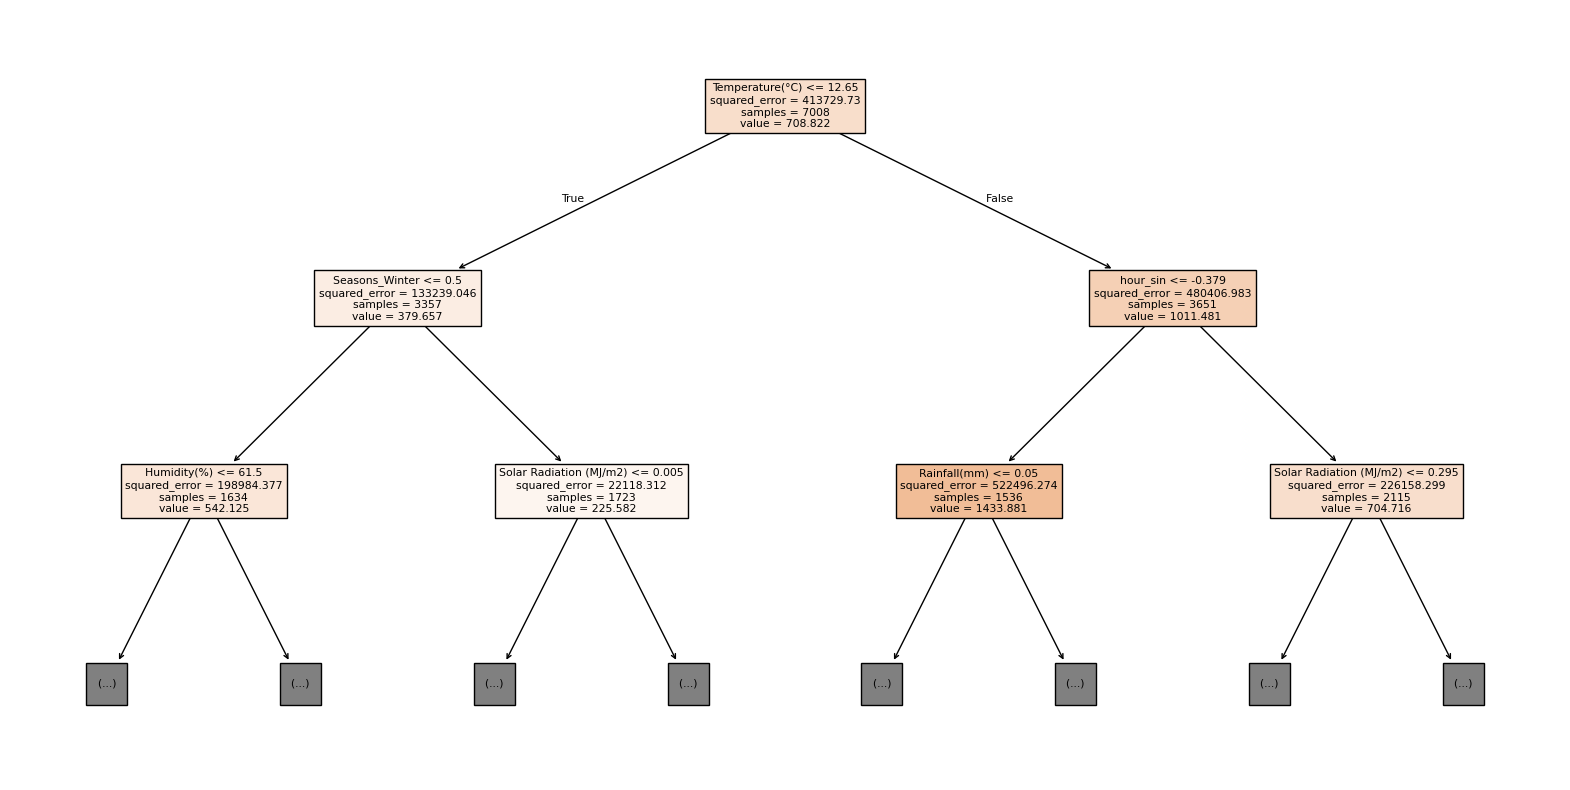

In [29]:
plt.figure(figsize=(20, 10))
plot_tree(
    grid_search.best_estimator_, filled=True, feature_names=X.columns, max_depth=2
)
plt.show()

### Random Forest

In [30]:
rand = RandomForestRegressor(random_state=17)

In [31]:
grid_search = GridSearchCV(
    estimator=rand,
    param_grid={
        "n_estimators": [10, 20, 30],
        "max_depth": [10, 15, 20, 25],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["log2", "sqrt"],
    },
    cv=kfold,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mess

In [32]:
get_and_save_rmse("Random Forest", grid_search)

Train RMSE: 98.31468382198008
Test RMSE: 239.90095003878528


TODO

### Gradient Boosting


In [33]:
gbr_model = HistGradientBoostingRegressor(random_state=17)

grid_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=17),
    param_grid={
        "max_depth": [5, 7],
        "learning_rate": [0.01, 0.05],
        "max_iter": [200, 300],
        "max_leaf_nodes": [60, 50, 70],
        "l2_regularization": [0.0, 1.0, 10.0],
    },
    cv=kfold,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'l2_regularization': [0.0, 1.0, ...], 'learning_rate': [0.01, 0.05], 'max_depth': [5, 7], 'max_iter': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [34]:
get_and_save_rmse("Gradient Boosting Tree", grid_search)

Train RMSE: 143.39395124714932
Test RMSE: 224.86127241082522


### Verleich der Test- und Trainingsfehler

In [35]:
best_models

,train_rmse,test_rmse
Linear Regression,433.467020,434.827561
Polynomial Regression,297.225408,311.421192
Decision Tree with Pruning,194.680279,291.121740
Random Forest,98.314684,239.900950
Gradient Boosting Tree,143.393951,224.861272


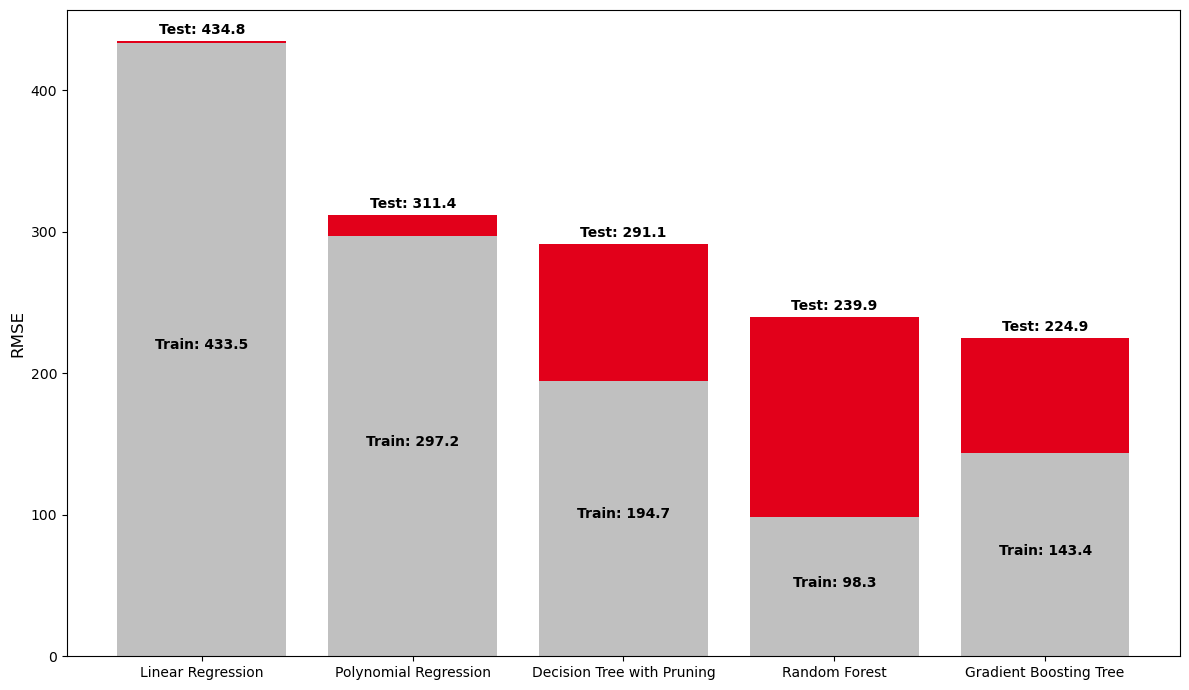

In [57]:
plt.figure(figsize=(12, 7))
plt.bar(best_models.index, best_models["test_rmse"], color="#E2001A")
plt.bar(best_models.index, best_models["train_rmse"], color="silver")
plt.ylabel("RMSE", fontsize=12)
for i, row in best_models.iterrows():
    plt.text(
        i,
        row["test_rmse"] + 5,
        f"Test: {row['test_rmse']:.1f}",
        ha="center",
        fontweight="bold",
    )
    plt.text(
        i,
        row["train_rmse"] / 2,
        f"Train: {row['train_rmse']:.1f}",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

#### Übersicht der Ergebnisse der besten Modelle

| Linear Regression | Polynomial Regression | Decision Tree| Random Forest |Gradient Boosting Tree|
| ----------------- | --------------------- |--------------|---------------|---------------------|
|hoher Bias | hoher Bias| Varianz |höchste Varianz| bester Bias-Varianz Tradeoff|
| Underfitting|Underfitting |Overfitting| Overfitting | bester Test-Fehler|

## Evaluation


Das final gewählte Modell ist der Gradient Boosting Tree, da dieser den besten Bias-Variance-Tradeoff hat. 

Wir evaluieren das Modell anschließend auf den bisher ausgeschlossenen Test-Daten.

In [63]:
y_pred = grid_search.best_estimator_.predict(X_test)

In [71]:
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Finale Performance auf dem Test-Set")
print(f"RMSE: {final_rmse:.2f}")



Finale Performance auf dem Test-Set
RMSE: 219.25


Die relative Genauigkeit beträgt in etwa 31% in Bezug auf die durchschnittlich ausgeliehenen Fahrrädern und ist somit schon viel besser.

Die Performance liegt sehr nah an dem Validierungs-Fehler ``219.25`` zu `224.9`. Das heißt, dass das Model nicht nur zufüllig gut ist, sondern auch allgemein besser als die anderen Modelle.

Die verleibenden Fehlerpunkte könnten auf verschiedene Faktoren zurückzuführen sein, wie zum Beispiel Wochenenden, lokale Events oder plötzliche Wetterumschwünge zu Stoßzeiten, welche nicht genau im Datensatz representiert sind.